In [4]:
import numpy as np
from bayesian_wrapper import GenerateCrossSection, RunBolsig, refcrs
from swarmData import swarmData
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

### Test GenerateCrossSection

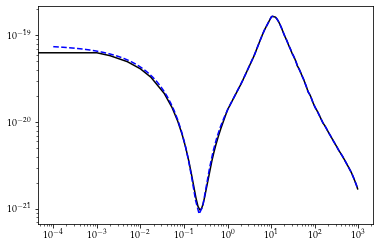

In [2]:
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
testcrs = GenerateCrossSection(theta_ref)

plt.figure(1)
for c in refcrs.crs:
    if ((c.colType==0) or (c.colType==1)):
        plt.loglog(c.data[:,0],c.data[:,1],'-k')
for c in testcrs.crs:
    if ((c.colType==0) or (c.colType==1)):
        plt.loglog(c.data[:,0],c.data[:,1],'--b')

### Test RunBolsig

In [3]:
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])
testcrs = GenerateCrossSection(theta_ref,filename="./bayesian-bolsig/crs/test-crs.txt")

outputs = RunBolsig(dataDir="./bayesian-bolsig")

### Run time measurements

In [4]:
theta_ref = np.array([-1.489, 65.0, -82.9, 0.881])

from time import perf_counter
times = np.zeros((3,))

Ntest = 10
for k in range(Ntest):
    tic = perf_counter()
    testcrs = GenerateCrossSection(theta_ref,filename="./bayesian-bolsig/crs/test-crs.txt")
    toc = perf_counter()
    times[0] += toc - tic

    outputs, times_bolsig = RunBolsig(dataDir="./bayesian-bolsig",check_time=True)
    times[1:] += times_bolsig
times /= Ntest
print(times)

[0.0092005  2.88553997 0.00433142]


In [3]:
import swarmData
filename = "../swarm/" + swarmData.swarmDatasets[-1] + ".txt"
testData = swarmData.swarmData(filename)
print(testData.Ndatasets)
print(testData.datasets[0].variables)
testData.ConvertData()
print(testData.datasets[0].variables)
print(testData.datasets[0].variables['DLN']*0.1/3)

1
{'E/N': array([ 0.25,  0.3 ,  0.35,  0.4 ,  0.5 ,  0.6 ,  0.7 ,  0.8 ,  1.  ,
        1.2 ,  1.4 ,  1.7 ,  2.  ,  2.5 ,  3.  ,  3.5 ,  4.  ,  4.5 ,
        5.  ,  6.  ,  7.  ,  8.  , 10.  , 12.  , 14.  , 17.  , 20.  ,
       25.  , 30.  , 35.  , 40.  , 50.  ]), 'W': array([ 213000.,  220000.,  229000.,  236000.,  249000.,  260000.,
        271000.,  280000.,  293000.,  306000.,  320000.,  335000.,
        344000.,  362000.,  381000.,  395000.,  412000.,  438000.,
        475000.,  564000.,  654000.,  761000.,  956000., 1170000.,
       1340000., 1630000., 1880000., 2240000., 2710000., 3110000.,
       3440000., 4120000.]), 'DLN': array([2.58e+22, 2.62e+22, 2.39e+22, 2.35e+22, 2.22e+22, 2.13e+22,
       1.99e+22, 1.85e+22, 1.77e+22, 1.67e+22, 1.59e+22, 1.38e+22,
       1.36e+22, 1.24e+22, 1.15e+22, 1.22e+22, 1.21e+22, 1.57e+22,
       1.88e+22, 2.36e+22, 2.96e+22, 3.18e+22, 3.52e+22, 3.37e+22,
       3.50e+22, 3.48e+22, 3.45e+22, 3.51e+22, 3.41e+22, 3.54e+22,
       3.38e+22, 3.48e+22